In [1]:
import pennylane as qp
qml = qp
import numpy as np

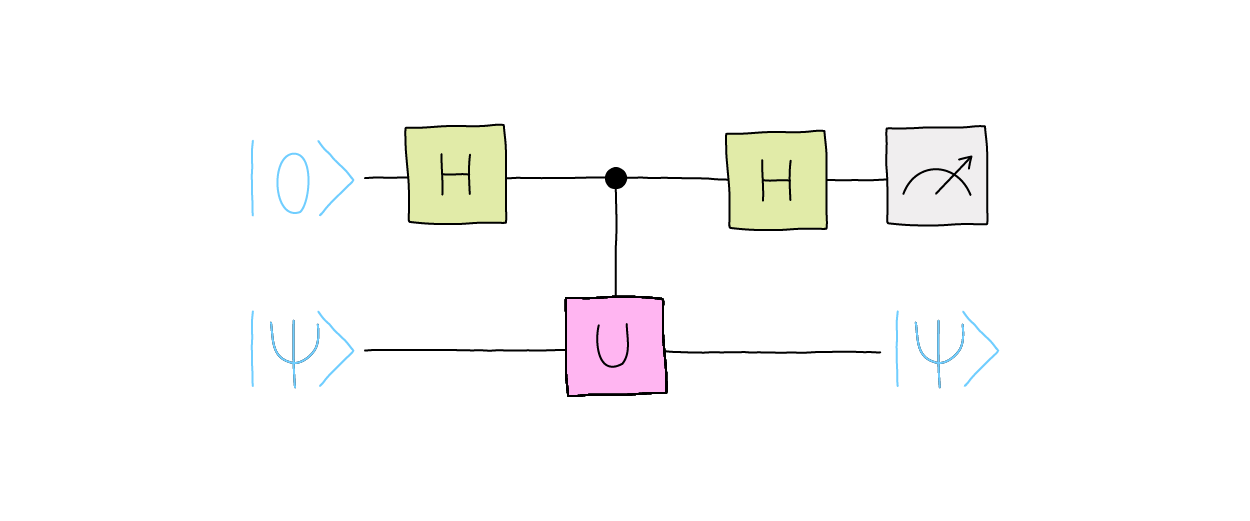

In [2]:
dev = qp.device("default.qubit", wires=2)

@qp.qnode(dev)
def guess_the_unitary(unitary):
    """Given a unitary that performs a Z or a -Z operation
    on a qubit, guess which one it is.
    
    Args: 
        U (array[complex]): A unitary matrix, guaranteed to be either Z or -Z.
    
    Returns:
        array [int]:  Probabilities on the first qubit
        using qp.probs()
    """
    ##################
    # YOUR CODE HERE #
    ##################  
    qp.Hadamard(wires=0)
    qp.ControlledQubitUnitary(unitary, wires=[0, 1])
    qp.Hadamard(wires=0)

    return qp.probs(0)

# Z gate 
U = qp.PauliZ.compute_matrix() 

# -Z gate
U = (-1)*qp.PauliZ.compute_matrix()

print(guess_the_unitary(U))

[0. 1.]


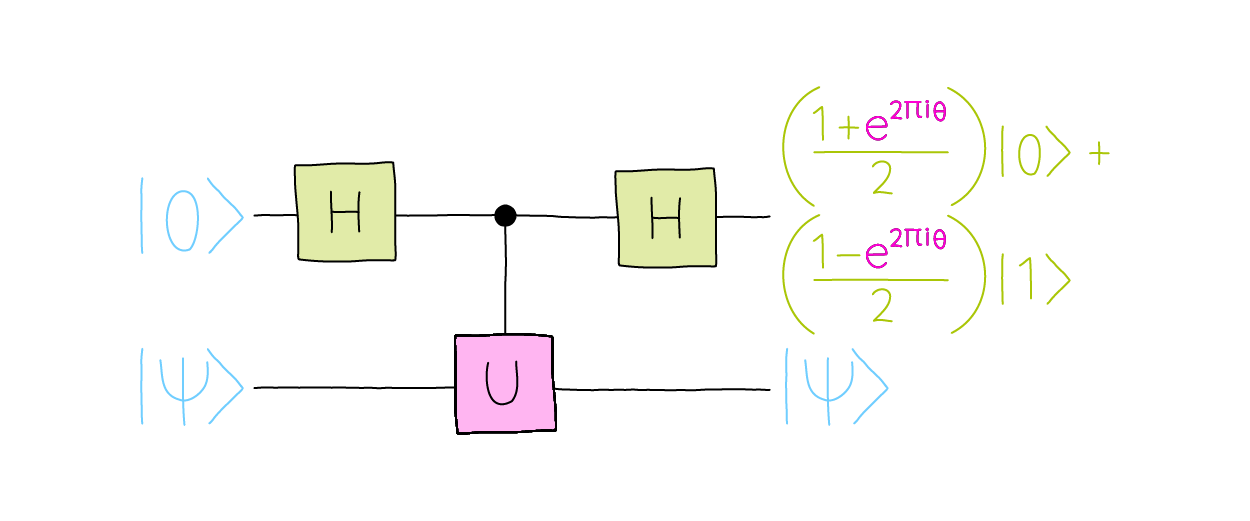

In [3]:
dev = qp.device("default.qubit", wires=2)
        
@qp.qnode(dev)
def phase_kickback_X(eigenvector):
    """ Given an eigenvector of X, 
    apply the phase kickback circuit to observe 
    the probabilities on the control wire
    
    Args: 
        eigenvector(String): A string "plus" or "minus" depicting 
        the eigenvector of X
    
    Returns:
        array[int]: Measurement outcome on the first qubit using qp.probs()
    """
    # Prepare |ψ>
    ##################
    # YOUR CODE HERE #
    ##################
    if eigenvector != "plus":
	    qp.PauliX(wires=1)
    qp.Hadamard(wires=1)
    
    # Phase kickback
    ##################
    # YOUR CODE HERE #
    ##################
    qp.Hadamard(wires=0)
    qp.CNOT(wires=[0,1])
    qp.Hadamard(wires=0)
 
    return qp.probs(wires=[0])   

print(phase_kickback_X("plus"))
print(phase_kickback_X("minus"))

# MODIFY EIGENVALUES BELOW 
eigenvalue_of_X_plus = 1
eigenvalue_of_X_minus = -1

[1. 0.]
[0. 1.]
